# Clustering Pipeline — Full Evaluation

End-to-end patch-embedding clustering: SSL features → L2 + PCA-whiten →
kNN graph → Leiden (Traag et al. 2019) → image-level statistics on
the resulting per-image cluster-frequency vectors.

**Key design decisions** (adapted for small-N microscopy data):
- Clustering in **PCA-whitened space** directly, not UMAP (Chari &
  Pachter 2023: UMAP manifolds are unstable at small N and can create
  spurious structure). UMAP-2D is used only for visualisation.
- **Adaptive Leiden k** scaled to dataset size (PhenoGraph k=30 was
  designed for N=15 000+; Levine et al. 2015).
- All inferential statistics at **image level**, not patch level,
  to avoid pseudoreplication (patches from the same image are
  spatially correlated; Caicedo et al., Nat Methods 2017).

**Pipeline:**
1. Imports & setup
2. Configuration
3. Output directory, logger, seed & device
4. Load checkpoint & build encoder
5. Build dataset
6. Extract patch embeddings
8. L2 normalisation + PCA whitening
9. UMAP-2D visualisation (not used for clustering)
10. Leiden clustering in PCA space + bootstrap stability
13. Cluster size statistics
14. Permutation null ARI
15. Image-level cross-validation — grouped half-split label transfer
16. Cluster characterisation — medoid grids
17. Per-image cluster frequencies & chi² independence (Monte Carlo fallback)
18. Cluster purity by source image
19. Treatment-group statistical analysis (chi², MMD, PERMANOVA, per-cluster KW)
20. Group-level visualisations (heatmaps, annotated boxplots, UMAP)
21. Save results & write cluster labels to index.csv
22. Run summary

---
## 1 — Imports & setup

In [1]:
%matplotlib inline

import os, sys, json, time, logging
from datetime import datetime
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
NB_DIR = Path.cwd().resolve()
REPO_ROOT = NB_DIR
while REPO_ROOT.parent != REPO_ROOT and not (REPO_ROOT / '.git').is_dir():
    REPO_ROOT = REPO_ROOT.parent
ROOT = REPO_ROOT / 'src'
for p in (ROOT, REPO_ROOT):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))
print('REPO_ROOT:', REPO_ROOT)
print('ROOT     :', ROOT)

REPO_ROOT: /auto/brno2/home/anokhver/thesis
ROOT     : /auto/brno2/home/anokhver/thesis/src


In [3]:
from synaptic_ssl.training.config import ModelCfg
from synaptic_ssl.training.seeding import seed_everything
from synaptic_ssl.training.logging import setup_logger
from synaptic_ssl.training.augment import ValSingleViewTransform
from synaptic_ssl.training.data import TransformedSubset
from synaptic_ssl.models import build_swin_encoder, count_params
from synaptic_ssl.utils_data.patch_dataset import PatchDataset

from synaptic_ssl.clustering.pipeline import (
    ClusterCfg,
    extract_patch_embeddings,
    auto_pca_dim, subtract_control_mean, l2_then_pca_whiten,
    adaptive_leiden_k,
    knn_igraph,
    fit_umap_2d,
    leiden_sweep, bootstrap_stability, pick_resolution,
    cluster_size_stats, permutation_null_ari,
    image_level_cv,
    cluster_medoids,
    per_image_cluster_frequencies, chi2_independence,
    cluster_purity_by_image,
    group_cluster_test, permanova_frequencies,
    per_cluster_kruskal_wallis,
    write_cluster_columns,
)
from synaptic_ssl.clustering.viz import (
    plot_singular_value_spectrum,
    plot_resolution_stability,
    plot_2d_clusters,
    plot_cluster_grid,
    plot_image_cluster_heatmap,
    plot_image_level_umap,
    plot_intra_image_entropy,
    plot_2d_groups,
    plot_group_cluster_heatmap,
    plot_group_frequency_boxplots,
)

print('All imports OK')

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


All imports OK


---
## 2 — Configuration

In [4]:
from types import SimpleNamespace


# ── Treatment-group mapping ──────────────────────────────────────────────────────────
# Patterns matched against source_image filename (upper-cased).
# More specific patterns come first so e.g. PSYHARMIN is not
# misclassified as PSY.
GROUP_PATTERNS: list[tuple[str, str]] = [
    ('PSYHARMIN',    'Psilocybin + harmine'),
    ('NORPSIHARMIN', 'Norpsilocin + harmine'),
    ('BAEOHARMIN',   'Baeocystin + harmine'),
    ('NORPSI',       'Norpsilocin'),
    ('BAEO',         'Baeocystin'),
    ('PSY',          'Psilocybin'),
    ('PSI',          'Psilocin'),
    ('KONTROLA',     'Control'),
]


def classify_image(name: str) -> str | None:
    """Return the treatment group for a source_image filename, or None."""
    upper = name.upper()
    for pattern, group in GROUP_PATTERNS:
        if pattern in upper:
            return group
    return None


def build_group_map(source_images) -> dict[str, str]:
    """Auto-build group_map from source_image filenames."""
    gm = {}
    for img in set(source_images):
        g = classify_image(str(img))
        if g is not None:
            gm[str(img)] = g
    return gm


# ── Paths ─────────────────────────────────────────────────────────────────
# Point encoder_ckpt at any checkpoint — works with both the pretrained
# SSL encoder and a from-scratch (random-init) run.
cfg_nb = SimpleNamespace(
    # --- Paths ---
    encoder_ckpt      = '../../data/training_outputs/simmim_vicreg_pretrain_tinny22k_default_20260519_022446/best_model.pt',
    data_root         = '../../data/patches_128_from_zip/20251030',
    output_dir        = '../outputs/clustering_full',
    embedding_cache   = '../outputs/clustering_full/embeddings_full.npy',

    # --- Data ---
    exclude_patterns  = [],
    batch_size        = 64,
    num_workers       = 0,

    # group_map is built automatically after embeddings are extracted
    # (see section 6). Override here if you need manual control:
    group_map = None,

    seed = 42,
)

In [5]:
from synaptic_ssl.clustering.pipeline import ClusterCfg

cluster_cfg = ClusterCfg(
    seed=cfg_nb.seed,
    embedding_cache=cfg_nb.embedding_cache,

    # ── PCA dimensionality ────────────────────────────────────────────────
    # None → auto: smallest d with cumulative explained variance ≥ 95%
    # (see auto_pca_dim). Pooled Swin features sit in 768 dims with
    # effective rank ≈ 5–22 on this data (RankMe; Garrido et al.,
    # ICML 2023), so a fixed cap like Scanpy's library default of 50
    # (Wolf et al., Genome Biol 2018 — a transcriptomics default, not
    # a methodological prescription) over-allocates and amplifies
    # noise PCs once PCA(whiten=True) rescales them to unit variance.
    pca_dim              = None,

    # ── Control-mean centering (inspired by TVN; Ando et al. 2017) ──
    control_reference_pattern = None,   # e.g. 'KONTROLA' to subtract control mean

    # ── UMAP for visualisation only (McInnes et al. 2018, §min_dist) ──
    umap2_n_neighbors    = 30,     # UMAP default 15; 30 for smoother layout
    umap2_min_dist       = 0.1,    # UMAP docs default for visualisation

    # ── Leiden (Traag et al. 2019) ──────────────────────────────────────
    # k is auto-scaled based on N when leiden_k_auto=True.
    # PhenoGraph (Levine et al. 2015) used k=30 at N=15 000+;
    # adaptive_leiden_k targets ~1.5% connectivity.
    leiden_k             = 30,      # default / upper bound
    leiden_k_auto        = True,
    leiden_resolutions   = (0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0),

    # ── Bootstrap stability (B=100: Hennig 2007, Von Luxburg 2010;
    #    frac=0.8: Lange et al. 2004 §2.1) ──
    bootstrap_b          = 100,
    bootstrap_frac       = 0.8,

    # ── Image-level cross-validation ─────────────────────────────────
    # Repeated grouped half-splits with kNN label transfer in PCA space
    # (adapted from Caicedo et al. 2017 for small N).
    cv_n_repeats         = 20,
    cv_k_neighbors       = 5,

    # ── Per-cluster Kruskal-Wallis posthoc multiple-comparison correction ──
    # Benjamini-Hochberg FDR (Benjamini & Hochberg 1995): less
    # conservative than Bonferroni across many cluster-wise tests.
    kw_correction        = 'bh',
)

---
## 3 — Output directory, logger, seed & device

In [6]:
RUN_TS = datetime.now().strftime('%Y%m%d_%H%M%S')
save_dir = Path(cfg_nb.output_dir) / f'run_{RUN_TS}'
save_dir.mkdir(parents=True, exist_ok=True)

logger = setup_logger('clustering', save_dir / 'run.log')
logger.info(f'encoder checkpoint = {cfg_nb.encoder_ckpt}')
logger.info(f'data root          = {cfg_nb.data_root}')
logger.info(f'save dir           = {save_dir}')

_ = seed_everything(cfg_nb.seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logger.info(f'device = {device}')

2026-05-19 16:23:50 | INFO    | encoder checkpoint = ../../data/training_outputs/simmim_vicreg_pretrain_tinny22k_default_20260519_022446/best_model.pt
2026-05-19 16:23:50 | INFO    | data root          = ../../data/patches_128_from_zip/20251030
2026-05-19 16:23:50 | INFO    | save dir           = ../outputs/clustering_full/run_20260519_162350
2026-05-19 16:23:50 | INFO    | device = cuda


---
## 4 — Load checkpoint & build encoder

In [7]:
ckpt_path = Path(cfg_nb.encoder_ckpt)
if not ckpt_path.exists():
    raise FileNotFoundError(f'checkpoint not found: {ckpt_path}')

ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
logger.info(f'ckpt keys = {sorted(ckpt.keys())}')

model_cfg = ModelCfg()
encoder = build_swin_encoder(model_cfg).to(device)

# Robust loading: works with pretrained SSL, from-scratch, and MoBY checkpoints
if 'encoder_state_dict' in ckpt:
    encoder.load_state_dict(ckpt['encoder_state_dict'])
elif 'model_state_dict' in ckpt:
    # Full model checkpoint: extract encoder (swinViT.) prefix
    full_sd = ckpt['model_state_dict']
    enc_sd = {k[len('swinViT.'):]: v for k, v in full_sd.items() if k.startswith('swinViT.')}
    if not enc_sd:
        enc_sd = full_sd
    # Only load matching keys
    target_sd = encoder.state_dict()
    matched = {k: v for k, v in enc_sd.items() if k in target_sd and v.shape == target_sd[k].shape}
    encoder.load_state_dict(matched, strict=False)
    logger.info(f'Loaded {len(matched)}/{len(target_sd)} encoder params from model_state_dict')
else:
    # Assume the checkpoint IS the state_dict
    target_sd = encoder.state_dict()
    matched = {k: v for k, v in ckpt.items() if k in target_sd and v.shape == target_sd[k].shape}
    encoder.load_state_dict(matched, strict=False)
    logger.info(f'Loaded {len(matched)}/{len(target_sd)} encoder params (raw state_dict)')

init_source = ckpt.get('init_source', 'unknown')
encoder.eval()
logger.info(f'encoder params = {count_params(encoder) / 1e6:.2f} M, init_source = {init_source}')
print(f'Encoder loaded: {count_params(encoder) / 1e6:.2f}M params, source: {init_source}')

2026-05-19 16:23:50 | INFO    | ckpt keys = ['all_val_metrics', 'channel_mean', 'channel_std', 'encoder_state_dict', 'epoch', 'heads_state_dict', 'optimizer_state_dict', 'scaler_state_dict', 'scheduler_state_dict', 'train_loss', 'val_metric']
2026-05-19 16:23:51 | INFO    | encoder params = 32.24 M, init_source = unknown


Encoder loaded: 32.24M params, source: unknown


---
## 5 — Build dataset

Use the **full** dataset for clustering (no train/val split).
SSL pretraining is label-free, so there is no data-leakage concern
(Chen et al. 2020 SimCLR §B.7; Caron et al. 2021 DINO §4.2).

In [8]:
raw_ds = PatchDataset(
    root=cfg_nb.data_root,
    exclude_patterns=cfg_nb.exclude_patterns,
)

# Channel statistics from checkpoint (if available)
ch_mean = torch.tensor(ckpt.get('channel_mean', [0.0, 0.0, 0.0]))
ch_std  = torch.tensor(ckpt.get('channel_std',  [1.0, 1.0, 1.0]))

transform = ValSingleViewTransform(ch_mean=ch_mean, ch_std=ch_std)
full_ds = TransformedSubset(raw_ds, transform=transform)

logger.info(f'Dataset: {len(raw_ds)} patches (full dataset, no split)')

2026-05-19 16:23:51 | INFO    | Dataset: 22032 patches (full dataset, no split)


---
## 6 — Extract patch embeddings

Globally-pooled deepest-stage features from the frozen encoder.
Cached to disk so re-runs are instant.

In [9]:
# Cache path includes checkpoint name to avoid conflicts between runs
ckpt_stem = Path(cfg_nb.encoder_ckpt).parent.name
cache_dir = Path(cluster_cfg.embedding_cache).parent if cluster_cfg.embedding_cache else None
if cache_dir:
    cache_path = cache_dir / f'embeddings_{ckpt_stem}.npy'
else:
    cache_path = None

In [10]:
Z, filenames, source_images, image_indices = extract_patch_embeddings(
    encoder, full_ds,
    device=device,
    batch_size=cfg_nb.batch_size,
    num_workers=cfg_nb.num_workers,
    cache_path=str(cache_path) if cache_path else None,
)
logger.info(f'Embeddings: N={Z.shape[0]}, D={Z.shape[1]}')
logger.info(f'Unique images: {len(set(source_images))}')
print(f'Embeddings: N={Z.shape[0]}, D={Z.shape[1]}, images={len(set(source_images))}')

2026-05-19 16:24:56 | INFO    | Embeddings: N=22032, D=1536
2026-05-19 16:24:56 | INFO    | Unique images: 68


Embeddings: N=22032, D=1536, images=68


In [11]:
# Singular values of centered embeddings (used by the spectrum plot below).
Z_t = torch.from_numpy(Z)
_Zc = (Z_t - Z_t.mean(dim=0, keepdim=True)).float()
S = torch.linalg.svdvals(_Zc).cpu().numpy()


---
## 8 — L2 normalisation + PCA whitening

L2-normalisation projects embeddings onto the unit hypersphere before PCA
(Wang & Isola 2020). PCA dimensionality is **auto-selected** as the
smallest `d` with cumulative explained variance ≥ 95% (`auto_pca_dim`);
with `whiten=True` every retained PC is rescaled to unit variance, so
letting `d` exceed the effective rank of the encoder features (Garrido
et al., RankMe, ICML 2023) just amplifies noise directions into the kNN
distance. Scanpy's `n_comps=50` library default (Wolf et al., Genome
Biol 2018) is a transcriptomics convention for sparse gene-expression
matrices and is not appropriate for 768-D pooled Swin features.

**Clustering happens directly in this PCA space** — we skip the UMAP-15D
intermediate step that single-cell pipelines use, because at our N UMAP
manifolds are unstable and can create spurious clusters (Chari & Pachter
2023). UMAP is used only for 2D visualisation plots.

In [12]:
# Optional control-mean centering
Z_proc = Z.copy()
if cluster_cfg.control_reference_pattern:
    Z_proc = subtract_control_mean(Z_proc, source_images, cluster_cfg.control_reference_pattern)
    logger.info(f'control-mean centering applied with pattern: {cluster_cfg.control_reference_pattern}')

# Auto-select PCA dimensionality
pca_dim = cluster_cfg.pca_dim
if pca_dim is None:
    pca_dim = auto_pca_dim(
        Z_proc,
        target_var=cluster_cfg.pca_dim_target_var,
        hard_cap=cluster_cfg.pca_dim_max,
    )
logger.info(f'PCA dim = {pca_dim}')

P, pca_model, cum_var = l2_then_pca_whiten(Z_proc, n_components=pca_dim, seed=cluster_cfg.seed)
logger.info(f'PCA whitened: shape={P.shape}, cumulative var={cum_var:.3f}')
print(f'PCA dim: {pca_dim},  cumulative variance: {cum_var:.3f}')

2026-05-19 16:26:05 | INFO    | PCA dim = 52
2026-05-19 16:26:07 | INFO    | PCA whitened: shape=(22032, 52), cumulative var=0.950


PCA dim: 52,  cumulative variance: 0.950


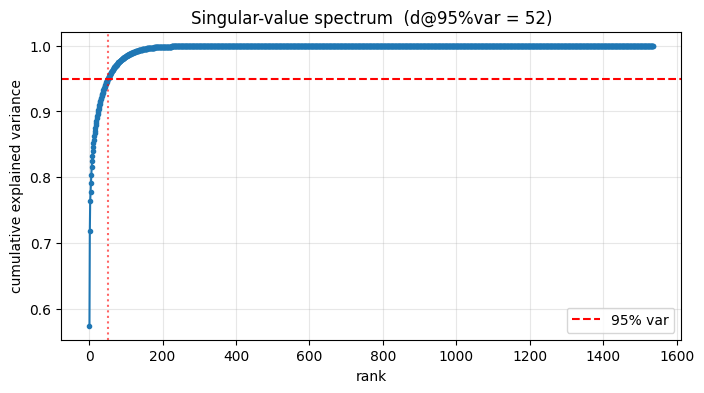

In [13]:
# Singular-value spectrum
fig, ax = plt.subplots(figsize=(8, 4))
plot_singular_value_spectrum(S, ax=ax, mark_target_var=cluster_cfg.pca_dim_target_var)
fig.savefig(save_dir / 'singular_value_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)

---
## 9 — UMAP-2D visualisation

UMAP-2D for **visualisation only** (larger `min_dist` avoids misleading
density). Clustering uses PCA space directly — see §8.

In [14]:
# UMAP-2D for visualisation only (not used for clustering)
U2 = fit_umap_2d(P, cfg=cluster_cfg)
logger.info(f'UMAP-2D (vis): shape={U2.shape}')
print(f'UMAP-2D done (visualisation only)')

2026-05-19 16:28:59 | INFO    | UMAP-2D (vis): shape=(22032, 2)


UMAP-2D done (visualisation only)


---
## 10 — Leiden clustering in PCA space + bootstrap stability

kNN graph is built directly on PCA-whitened features (no UMAP intermediate).
Leiden k is **auto-scaled** based on dataset size: PhenoGraph (Levine et al.
2015) used k=30 at N=15 000+; at N≈1000 the same k produces an
over-connected graph that washes out local density.

Resolution sweep with 80% bootstrap resampling → 1-NN propagation → ARI
vs full partition (Hennig 2007, Lange et al. 2004).
Pick the resolution with the highest mean ARI; tie-break by fewer clusters.

In [ ]:
# Adaptive k based on dataset size
N = P.shape[0]
effective_k = adaptive_leiden_k(N, cluster_cfg.leiden_k) if cluster_cfg.leiden_k_auto else cluster_cfg.leiden_k
logger.info(f'Adaptive Leiden k: {effective_k} (N={N}, default={cluster_cfg.leiden_k})')
print(f'Adaptive Leiden k = {effective_k}  (N={N})')

# Cluster directly in PCA-whitened space (no UMAP intermediate)
summary, full = bootstrap_stability(
    P,
    resolutions=cluster_cfg.leiden_resolutions,
    k=effective_k,
    B=cluster_cfg.bootstrap_b,
    frac=cluster_cfg.bootstrap_frac,
    seed=cluster_cfg.seed,
    source_images=source_images,
)

best_res, best_ari, best_std, best_k = pick_resolution(summary, full)
labels_leiden = full[best_res]

logger.info(f'Best resolution: {best_res}  ARI={best_ari:.3f}±{best_std:.3f}  K={best_k}')
print(f'Best resolution: {best_res}')
print(f'  ARI = {best_ari:.3f} ± {best_std:.3f}')
print(f'  K   = {best_k} clusters')

for r in sorted(summary.keys()):
    m, s = summary[r]
    k = len(set(full[r]))
    marker = ' <<<' if r == best_res else ''
    print(f'  res={r:.2f}  ARI={m:.3f}±{s:.3f}  K={k}{marker}')

2026-05-19 16:28:59 | INFO    | Adaptive Leiden k: 30 (N=22032, default=30)


Adaptive Leiden k = 30  (N=22032)


In [ ]:
# Resolution stability plot
fig, ax = plt.subplots(figsize=(9, 4))
plot_resolution_stability(summary, full, ax=ax)
fig.savefig(save_dir / 'resolution_stability.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)

In [ ]:
# 2D scatter coloured by Leiden cluster
fig, ax = plt.subplots(figsize=(8, 7))
plot_2d_clusters(
    U2, labels_leiden, ax=ax,
    title=f'UMAP-2D — Leiden in PCA (res={best_res}, K={best_k}, k={effective_k})',
)
fig.savefig(save_dir / 'umap2d_leiden.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)

# Use Leiden labels as the primary clustering
labels = labels_leiden
stats = cluster_size_stats(labels)

logger.info(f'Cluster size stats: {stats}')
for k, v in stats.items():
    print(f'  {k}: {v}')

---
## 14 — Permutation null ARI

Shuffle PCs independently and re-run kNN+Leiden (in the same clustering
space) to estimate the ARI expected under the null (Witten & Tibshirani 2010).
Real ARI should exceed this distribution.

In [ ]:
# Null ARI: ARI between the real partition and clusterings of
# image-mean-shuffled embeddings. If structure were noise, the
# shuffled clustering would recover the same labels and null ARI
# would stay near the real partition; if structure is data-driven,
# null ARI collapses toward 0. (Not directly comparable to the
# bootstrap stability ARI, which measures reproducibility of the
# real partition under image-block resampling.)
null_mean, null_std, null_max = permutation_null_ari(
    P, labels, cfg=cluster_cfg, resolution=best_res,
    k=effective_k,
    source_images=source_images,
)
logger.info(f'Null ARI: {null_mean:.3f}±{null_std:.3f} (max={null_max:.3f})')
print(f'Null ARI (real vs shuffled):  '
      f'mean={null_mean:.3f} ± {null_std:.3f},  max={null_max:.3f}')
print(f'Bootstrap stability ARI (real vs resampled):  {best_ari:.3f}')
if null_max < 0.1:
    print('⇒ Null ARI ≈ 0: shuffled data does not recover the real '
          'clusters, so the structure is data-driven, not random.')
else:
    print(f'⇒ Null ARI is non-negligible (max={null_max:.3f}); '
          'inspect the permutation scheme before claiming the structure '
          'is data-driven.')

---
## 15 — Image-level cross-validation (label transfer)

Repeated grouped half-split CV: hold out all patches from half the images,
train kNN in PCA space on the remaining patches’ cluster labels, predict
the held-out patches, and measure ARI.

This tests whether the **embedding** generalises across biological samples
(Caicedo et al. 2017), without re-running UMAP+Leiden on tiny folds
(which is unreliable at small N). Reports median ± IQR over 20 splits.

In [ ]:
if cfg_nb.group_map is None:
    cfg_nb.group_map = build_group_map(source_images)
cv_median, cv_q25, cv_q75, cv_aris = image_level_cv(
    P, source_images, labels, cfg=cluster_cfg,
    group_map=cfg_nb.group_map if cfg_nb.group_map else None,
)
logger.info(f'Image-level CV: median ARI={cv_median:.3f}  IQR=[{cv_q25:.3f}, {cv_q75:.3f}]')
print(f'Image-level CV (label transfer, {cluster_cfg.cv_n_repeats} splits):')
print(f'  median ARI = {cv_median:.3f}')
print(f'  IQR        = [{cv_q25:.3f}, {cv_q75:.3f}]')

---
## 16 — Cluster characterisation — medoid grids

Per-cluster medoid + random samples (Caron et al. 2018 DeepCluster).

In [ ]:
medoids = cluster_medoids(
    P, labels,
    samples_per_cluster=cluster_cfg.samples_per_cluster,
    seed=cluster_cfg.seed,
)
logger.info(f'Medoids computed for {len(medoids)} clusters')

# Show medoid grid using the raw (un-transformed) dataset
fig = plot_cluster_grid(raw_ds, medoids, channel=0)
fig.savefig(save_dir / 'cluster_medoids.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)

---
## 17 — Per-image cluster frequencies & chi² independence

Build (images × clusters) frequency matrix and test whether
images have significantly different cluster compositions.

In [ ]:
freq, image_names, cluster_ids, counts = per_image_cluster_frequencies(
    labels, source_images,
)
chi2_val, chi2_p, chi2_dof, n_dropped, chi2_method = chi2_independence(
    counts, min_image_patches=cluster_cfg.chi2_min_image_patches,
    n_permutations=cluster_cfg.chi2_n_permutations, seed=cluster_cfg.seed,
)
# Image-level chi² of independence: tests whether *source images*
# (not biological groups) differ in cluster composition. This is a
# batch-effect sanity check, not the treatment-group test.
logger.info(f'image-level chi² (batch-effect check) = {chi2_val:.2f}, '
            f'p = {chi2_p:.4g}, dof = {chi2_dof}, '
            f'method = {chi2_method}, dropped = {n_dropped}')
print(f'Image-level chi² (batch-effect check, image × cluster, {chi2_method}):')
print(f'  chi² = {chi2_val:.2f},  p = {chi2_p:.4g},  dof = {chi2_dof}')
print(f'  images dropped (< {cluster_cfg.chi2_min_image_patches} patches): {n_dropped}')
print('  (treatment-group chi² is computed in §19a below.)')

In [ ]:
# Per-image cluster frequency heatmap
fig, ax = plt.subplots(figsize=(max(8, 0.4 * len(cluster_ids) + 2),
                                max(5, 0.2 * len(image_names) + 1)))
plot_image_cluster_heatmap(freq, image_names, cluster_ids, ax=ax)
fig.savefig(save_dir / 'image_cluster_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)

In [ ]:
# Image-level UMAP of frequency vectors
fig, ax = plt.subplots(figsize=(8, 7))
plot_image_level_umap(freq, image_names, seed=cluster_cfg.seed, ax=ax)
fig.savefig(save_dir / 'image_level_umap.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)

---
## 18 — Cluster purity by source image

Per-cluster normalised entropy of the source-image distribution.
1.0 = perfectly mixed across images, 0.0 = dominated by one image.
Clusters dominated by one image indicate batch effects (Caicedo et al. 2017).

In [ ]:
purity_rows = cluster_purity_by_image(labels, source_images)
for r in purity_rows:
    logger.info(f'  cluster {r["cluster"]}: size={r["size"]}, '
                f'n_images={r["n_images_present"]}, '
                f'norm_entropy={r["norm_entropy"]:.3f}')
    print(f'  c{r["cluster"]:>3d}  size={r["size"]:>5d}  '
          f'images={r["n_images_present"]:>3d}  '
          f'entropy={r["norm_entropy"]:.3f}')

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_intra_image_entropy(purity_rows, ax=ax)
fig.savefig(save_dir / 'cluster_purity.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)

---
## 19 — Treatment-group statistical analysis

All tests below require a populated `group_map` in the configuration.
They compare cluster-composition profiles between biological groups
(e.g. psilocybin vs harmine vs control).

**Tests:**
- **Group × cluster chi²** (or permutation chi² with image-level shuffling)
- **MMD permutation test** on per-image mean embeddings (Gretton et al. 2012)
- **PERMANOVA** on per-image frequency vectors (Anderson 2001)

In [ ]:
# Auto-build group_map from source_image filenames
if cfg_nb.group_map is None:
    cfg_nb.group_map = build_group_map(source_images)

has_groups = len(cfg_nb.group_map) > 0

if has_groups:
    groups_found = sorted(set(cfg_nb.group_map.values()))
    logger.info(f'Group map: {len(cfg_nb.group_map)} images mapped to {len(groups_found)} groups')
    print(f'Groups found: {groups_found}')
    for g in groups_found:
        n = sum(1 for v in cfg_nb.group_map.values() if v == g)
        print(f'  {g}: {n} images')
else:
    print('⚠ group_map is empty — skipping treatment-group analysis.')
    print('  No filename matched any GROUP_PATTERNS entry.')

### 19a — Image-level permutation χ² on group × cluster table (cross-check)

Cross-check of the primary PERMANOVA result using a different test statistic on the same unit of analysis (one observation per source image). p-value via 10 000 permutations of group labels across images.


In [ ]:
if has_groups:
    gtest = group_cluster_test(
        counts, image_names, cluster_ids, cfg_nb.group_map,
        seed=cluster_cfg.seed,
    )
    logger.info(f'Group test: method={gtest.method_used}, '
                f'chi²={gtest.statistic:.2f}, p={gtest.p_value:.4g}')
    logger.info(f'  groups: {gtest.group_names}')
    logger.info(f'  n_images_per_group: {gtest.n_images_per_group}')
    print(f'Method: {gtest.method_used}')
    print(f'chi² = {gtest.statistic:.2f},  p = {gtest.p_value:.4g}')
    print(f'Groups: {gtest.group_names}')
    print(f'Images per group: {gtest.n_images_per_group}')

In [ ]:
if has_groups:
    fig, ax = plt.subplots(figsize=(max(6, 0.4 * len(cluster_ids) + 2),
                                    max(3, 0.5 * len(gtest.group_names) + 1)))
    plot_group_cluster_heatmap(
        gtest.group_counts, gtest.group_names, gtest.cluster_ids, ax=ax,
    )
    fig.savefig(save_dir / 'group_cluster_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)

### 19b — PERMANOVA on per-image frequency vectors (primary multivariate test)

Primary group-level test: non-parametric multivariate PERMANOVA (Anderson 2001) on Bray-Curtis distances between per-image cluster-frequency vectors. The image is the unit of analysis, so patches from the same image are not treated as independent observations (Caicedo et al., Nat Methods 2017).


In [ ]:
if has_groups:
    perm_res = permanova_frequencies(
        freq, image_names, cfg_nb.group_map,
        metric=cluster_cfg.permanova_metric,
        n_permutations=cluster_cfg.permanova_n_permutations,
        seed=cluster_cfg.seed,
    )
    logger.info(f'PERMANOVA: F={perm_res.f_statistic:.3f}, '
                f'p={perm_res.p_value:.4g}, R²={perm_res.r_squared:.3f}')
    print(f'PERMANOVA:')
    print(f'  F = {perm_res.f_statistic:.3f}')
    print(f'  p = {perm_res.p_value:.4g}')
    print(f'  R² = {perm_res.r_squared:.3f}')
    print(f'  n per group: {perm_res.n_per_group}')

### 19c — Per-cluster Kruskal-Wallis posthoc (BH-FDR)

Posthoc to PERMANOVA: for each cluster, test whether the per-image frequency distribution differs across biological groups. The image is the unit of analysis. p-values are Benjamini-Hochberg corrected across clusters. PERMANOVA tells us *whether* groups differ overall; KW tells us *which clusters* drive that difference.


In [ ]:
if has_groups:
    kw_res = per_cluster_kruskal_wallis(
        freq, image_names, cluster_ids, cfg_nb.group_map,
        correction=cluster_cfg.kw_correction,
    )
    logger.info(f'Per-cluster KW ({kw_res.method}): '
                f'groups={kw_res.group_names}, '
                f'n_per_group={kw_res.n_per_group}')
    print(f'Per-cluster Kruskal-Wallis  (correction = {cluster_cfg.kw_correction}):')
    for cid, h, p_raw, p_adj in zip(
        kw_res.cluster_ids, kw_res.statistics,
        kw_res.p_values_raw, kw_res.p_values_corrected,
    ):
        if np.isnan(p_adj):
            print(f'  c{int(cid):>3d}  H=  nan   p=  nan   q=  nan')
            continue
        flag = '***' if p_adj < 0.001 else '**' if p_adj < 0.01 else '*' if p_adj < 0.05 else ''
        print(f'  c{int(cid):>3d}  H={h:6.2f}   p={p_raw:.4g}   q={p_adj:.4g}  {flag}')
    n_sig = int(np.sum(kw_res.p_values_corrected < 0.05))
    print(f'  ⇒ {n_sig} / {len(kw_res.cluster_ids)} clusters with q < 0.05')

---
## 20 — Group-level visualisations

In [ ]:
if has_groups:
    # UMAP-2D coloured by group
    fig, ax = plt.subplots(figsize=(8, 7))
    plot_2d_groups(
        U2, source_images, cfg_nb.group_map, ax=ax,
        title='UMAP-2D coloured by treatment group',
    )
    fig.savefig(save_dir / 'umap2d_groups.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)

In [ ]:
if has_groups:
    # Per-cluster frequency boxplots by group (annotated with KW q-values)
    q_vals = kw_res.p_values_corrected if kw_res.group_names else None
    fig = plot_group_frequency_boxplots(
        freq, image_names, cfg_nb.group_map, cluster_ids,
        q_values=q_vals,
    )
    fig.savefig(save_dir / 'group_frequency_boxplots.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)

---
## 21 — Save results & write cluster labels to index.csv

In [ ]:
# Save embeddings, labels, frequencies
np.save(save_dir / 'embeddings.npy', Z)
np.save(save_dir / 'labels_leiden.npy', labels_leiden)
np.save(save_dir / 'umap_2d.npy', U2)
np.save(save_dir / 'pca_whitened.npy', P)
np.save(save_dir / 'frequencies.npy', freq)
np.save(save_dir / 'image_names.npy', image_names)
np.save(save_dir / 'cluster_ids.npy', cluster_ids)
np.save(save_dir / 'filenames.npy', filenames)
np.save(save_dir / 'source_images.npy', source_images)

logger.info(f'Saved arrays to {save_dir}')
print(f'Saved to {save_dir}')

In [ ]:
# Write cluster labels into the patch-directory index.csv
write_summary = write_cluster_columns(
    cfg_nb.data_root, filenames,
    column_to_labels={
        'leiden_cluster': labels_leiden,
    },
)
logger.info(f'index.csv update: {write_summary}')
for col, info in write_summary.items():
    print(f'  {col}: {info}')

---
## 22 — Run summary

In [ ]:
summary = {
    'effective_leiden_k': effective_k,
    'pca_dim': pca_dim,
    'pca_cum_var': cum_var,
    'leiden_best_res': best_res,
    'leiden_ari': best_ari,
    'leiden_k': best_k,
    'cluster_gini': stats['gini'],
    'null_ari_mean': null_mean,
    'null_ari_max': null_max,
    'image_cv_median_ari': cv_median,
    'image_cv_q25': cv_q25,
    'image_cv_q75': cv_q75,
    'chi2_images': chi2_val,
    'chi2_images_p': chi2_p,
    'chi2_method': chi2_method,
    # n<3 → essentially no per-group power; surfaces NORPSIHARMIN-style cases.
    'underpowered_groups': (
        sorted([str(g) for g, n in perm_res.n_per_group.items() if n < 3])
        if has_groups else []
    ),
}

if has_groups:
    # Treatment-level results so the defence can quote concrete numbers
    # without grepping run.log.
    def _f(x):
        return None if np.isnan(x) else float(x)

    summary['group_chi2'] = _f(gtest.statistic)
    summary['group_chi2_p'] = _f(gtest.p_value)
    summary['group_chi2_method'] = gtest.method_used

    summary['permanova_f'] = _f(perm_res.f_statistic)
    summary['permanova_p'] = _f(perm_res.p_value)
    summary['permanova_r2'] = _f(perm_res.r_squared)
    summary['permanova_n_permutations'] = int(perm_res.n_permutations)
    summary['n_per_group'] = {
        str(k): int(v) for k, v in perm_res.n_per_group.items()
    }

    summary['kw_cluster_ids'] = [int(c) for c in kw_res.cluster_ids]
    summary['kw_q_values'] = [_f(q) for q in kw_res.p_values_corrected]
    summary['kw_n_significant_q05'] = int(
        np.nansum(kw_res.p_values_corrected < 0.05)
    )
    summary['kw_method'] = kw_res.method

with open(save_dir / 'summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

logger.info('=== RUN SUMMARY ===')
for k, v in summary.items():
    val = f'{v:.4f}' if isinstance(v, float) else str(v)
    logger.info(f'  {k}: {val}')
    print(f'  {k}: {val}')